In [100]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report ,confusion_matrix ,ConfusionMatrixDisplay ,accuracy_score

In [101]:
# Load the global social media dataset
df = pd.read_csv("tiktok_instagram_global_100countries.csv")

# Remove single outlier class 'Severe' to prevent empty stratification splits
df = df[df['addiction_level'] != 'Severe']

# Drop demographic and non-predictive keys, keeping physiological/behavioral features
X = df.drop([
    "user_id", "country", "age", "addiction_score", "year", 
    "addiction_pressure", "addiction_level", "ASI", "MHRI"
], axis=1)

y = df["addiction_level"]

# Quick check on the structural dimensions of features
X.info()

<class 'pandas.DataFrame'>
Index: 9999 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   internet_penetration         9999 non-null   float64
 1   mental_health_support_index  9999 non-null   float64
 2   gdp_index                    9999 non-null   float64
 3   youth_population_ratio       9999 non-null   float64
 4   baseline_addiction_pressure  9999 non-null   float64
 5   tiktok_minutes_daily         9999 non-null   float64
 6   instagram_minutes_daily      9999 non-null   float64
 7   night_usage_ratio            9999 non-null   float64
 8   scroll_velocity              9999 non-null   float64
 9   attention_span_score         9999 non-null   float64
 10  dopamine_dependency_score    9999 non-null   float64
 11  impulsivity_index            9999 non-null   float64
 12  sleep_hours                  9999 non-null   float64
 13  sleep_quality_index          9999 

In [102]:
# 80/20 train-test split using stratify to preserve the unbalanced class distributions
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training features shape: {X_tr.shape}")
print(f"Testing features shape : {X_ts.shape}")

Training features shape: (7999, 14)
Testing features shape : (2000, 14)


In [103]:
# Build a pipeline with scaling and a balanced logistic regression classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Train the model
pipeline.fit(X_tr, y_tr)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['internet_penetration','mental_health_support_index','gdp_index',..., 'impulsivity_index','sleep_hours','sleep_quality_index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [104]:
# Evaluate model predictions against the test set
y_pred = pipeline.predict(X_ts)

print(f"Accuracy Score:{accuracy_score(y_ts, y_pred):.2f}\n")

print("Classification Report:")
print(classification_report(y_ts, y_pred))


Accuracy Score:0.98

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.98      0.99      1736
         Low       0.96      1.00      0.98        24
      Medium       0.89      1.00      0.94       240

    accuracy                           0.98      2000
   macro avg       0.95      0.99      0.97      2000
weighted avg       0.99      0.98      0.99      2000



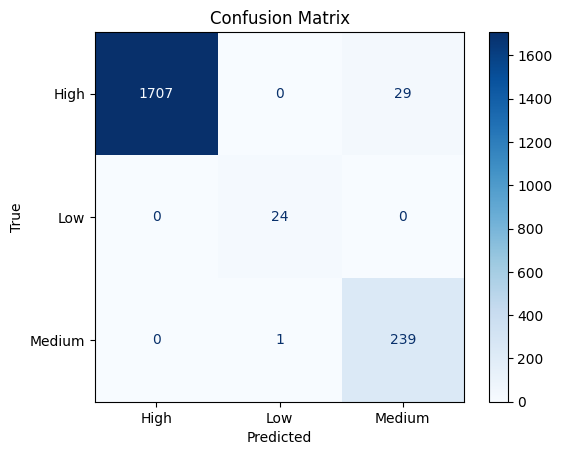

In [105]:


cm = confusion_matrix(y_ts, y_pred, labels=pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

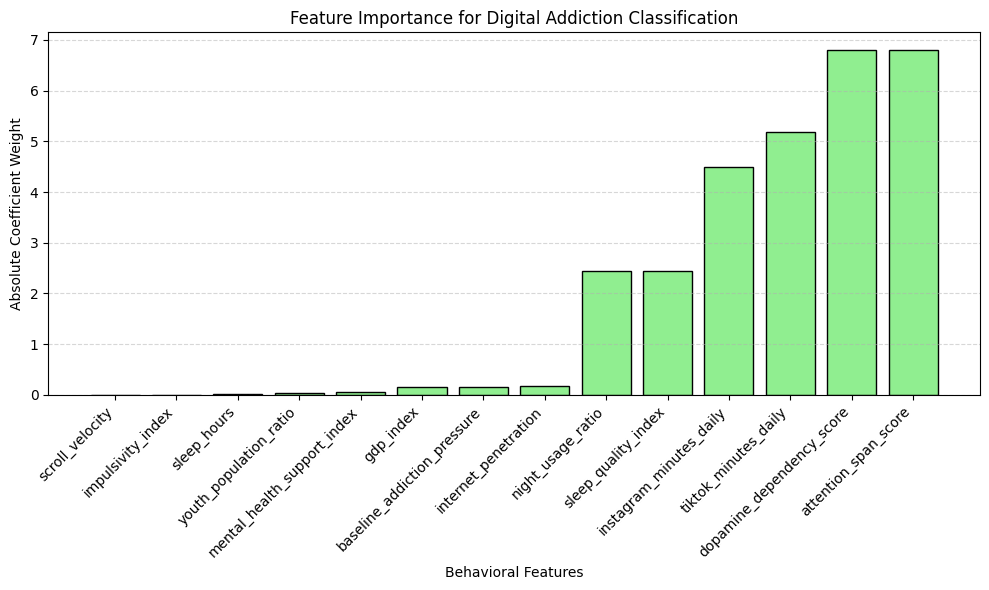

In [106]:
# Extract the statistical weights of the features from the trained model
weights = pipeline.named_steps['classifier'].coef_[0]
feature_names = X.columns
absolute_weights = np.abs(weights)

# Sort features by importance for cleaner visualization
indices = np.argsort(absolute_weights)

# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_names[indices], absolute_weights[indices], color='lightgreen', edgecolor='black')
plt.title('Feature Importance for Digital Addiction Classification')
plt.ylabel('Absolute Coefficient Weight')
plt.xlabel('Behavioral Features')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [107]:
import joblib


joblib.dump(pipeline, 'social_media_addiction_model.joblib')

['social_media_addiction_model.joblib']